## Group Project 1
## Group No 7797
## Submitted by: Vikas Gautam, Rishi
## mail-id: vikasgtm@gmail.com¶##

## Category: Equity, Stocks
## Step1 : Import the required libraries

In [1]:
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from statsmodels.tsa.api import VAR
from pandas.tseries.holiday import USFederalHolidayCalendar
from pandas.tseries.offsets import CustomBusinessDay
from sklearn.metrics import confusion_matrix

In [2]:
! pip install factor_analyzer

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 kB 1.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for factor_analyzer: filename=factor_analyzer-0.5.1-py2.py3-none-any.whl size=42568 sha256=d68924521795394949fbd0b33b5964597b8f5e0126c0778a7949e0c547044f45
  Stored in directory: /root/.cache/pip/wheels/24/59/82/6493618e30ed1cb7a013b9e1b0c9e17de80b04dfcef4ba8a4d
Successfully built factor_analyzer


In [3]:
import matplotlib.pyplot as plt
%matplotlib inline
import statsmodels
import statsmodels.api as sm
import numpy as np
from statsmodels.tsa.stattools import adfuller, kpss


import seaborn as sns
from numpy.linalg import eig

In [4]:

import pandas as pd
import numpy as np
import statsmodels.stats.api as sms
import statsmodels.formula.api as smf
import warnings                   # To ignore the warnings
warnings.filterwarnings("ignore")

In [5]:

import statsmodels.api as sm
from sklearn.linear_model import Lasso, LassoCV, Ridge, RidgeCV

plt.rcParams["figure.figsize"] = (10, 8)  # Figure size and width

## Step2 : Import the dataset from yahoo finance for
## ten stocks: "AAPL","MSFT","META","FORD","GM","TSLA","AMZN","GOOG","IBM","GE"
## from 2019-01 to 2024-04

In [6]:
import yfinance as yf
# Fetch historical data for Apple
ticker_symbol = ["AAPL","MSFT","META","FORD","GM","TSLA","AMZN","GOOG","IBM","GE"]
start_date = "2019-01-01"
end_date = "2024-04-30"
stock_data = yf.download(ticker_symbol, start=start_date, end=end_date)

[*********************100%***********************]  10 of 10 completed


In [7]:
df=pd.DataFrame()
for ticker in ticker_symbol:
    col=("Adj Close",ticker)
    str=ticker+"_Adj_Close"
    df[str]=stock_data[col]
df.head()

,AAPL_Adj_Close,MSFT_Adj_Close,META_Adj_Close,FORD_Adj_Close,GM_Adj_Close,TSLA_Adj_Close,AMZN_Adj_Close,GOOG_Adj_Close,IBM_Adj_Close,GE_Adj_Close
Date,,,,,,,,,,
2019-01-02,37.708595,95.310555,135.272705,13.4,31.090395,20.674667,76.956497,52.105282,83.291313,37.646240
2019-01-03,33.952534,91.804260,131.344543,13.0,29.805744,20.024000,75.014000,50.621113,81.628540,37.693016
2019-01-04,35.401947,96.074028,137.535889,13.4,30.803890,21.179333,78.769501,53.343830,84.816780,38.488018
2019-01-07,35.323147,96.196533,137.635605,13.5,31.755823,22.330667,81.475502,53.228245,85.416809,40.873066
2019-01-08,35.996521,96.894005,142.102142,13.4,32.171726,22.356667,82.829002,53.621330,86.631363,40.031284


## Generating Returns

In [8]:
df2=pd.DataFrame()
for ticker in ticker_symbol:
    str1=ticker+"_Adj_Close"
    str2=ticker+"_Return"
    df2[str2]=df[str1].pct_change()
df2.head()

,AAPL_Return,MSFT_Return,META_Return,FORD_Return,GM_Return,TSLA_Return,AMZN_Return,GOOG_Return,IBM_Return,GE_Return
Date,,,,,,,,,,
2019-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-03,-0.099608,-0.036788,-0.029039,-0.029851,-0.041320,-0.031472,-0.025241,-0.028484,-0.019963,0.001243
2019-01-04,0.042689,0.046509,0.047138,0.030769,0.033488,0.057697,0.050064,0.053786,0.039058,0.021091
2019-01-07,-0.002226,0.001275,0.000725,0.007463,0.030903,0.054361,0.034353,-0.002167,0.007074,0.061969
2019-01-08,0.019063,0.007250,0.032452,-0.007407,0.013097,0.001164,0.016612,0.007385,0.014219,-0.020595


In [9]:
df.dropna(inplace=True)
df2.dropna(inplace=True)


In [10]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
# Calculate daily returns
returns = df.pct_change().dropna()

# Add a constant to the model
X = sm.add_constant(returns)

# Fit the model
#model = sm.OLS(returns['AAPL_Adj_Close'], X.drop(columns=['AAPL_Adj_Close'])).fit()

# Print the summary
#print(model.summary())

# Calculate VIF
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns

# Calculate VIF for each feature
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# Display the VIF values
print(vif_data)#

           feature       VIF
0            const  1.008125
1   AAPL_Adj_Close  2.691967
2   MSFT_Adj_Close  3.459233
3   META_Adj_Close  2.006304
4   FORD_Adj_Close  1.046036
5     GM_Adj_Close  1.683059
6   TSLA_Adj_Close  1.436096
7   AMZN_Adj_Close  2.316272
8   GOOG_Adj_Close  2.778872
9    IBM_Adj_Close  1.564892
10    GE_Adj_Close  1.594933


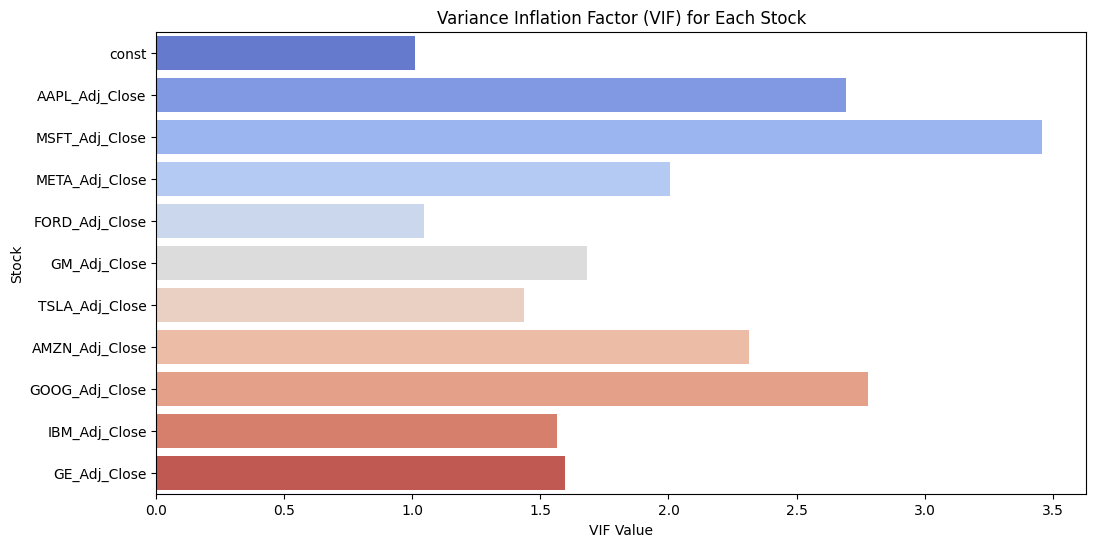

In [11]:
# Calculate VIF without adding a constant
# vif_data = pd.DataFrame()
# vif_data["feature"] = returns.columns
# vif_data["VIF"] = [variance_inflation_factor(returns.values, i) for i in range(returns.shape[1])]

# Plot VIF values
plt.figure(figsize=(12, 6))
sns.barplot(x="VIF", y="feature", data=vif_data, palette="coolwarm")
plt.title('Variance Inflation Factor (VIF) for Each Stock')
plt.xlabel('VIF Value')
plt.ylabel('Stock')
plt.show()

In [12]:
# Calculate the correlation matrix
correlation_matrix = df.corr()

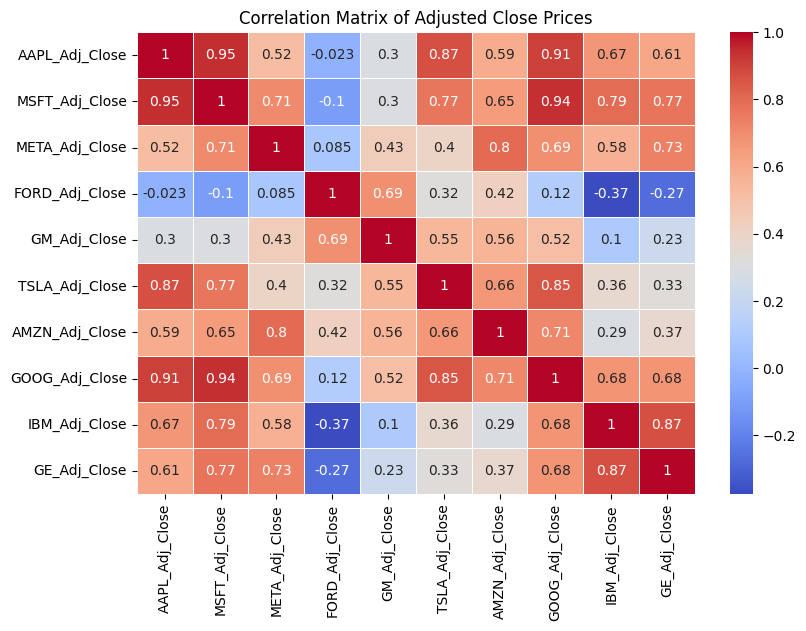

In [13]:
# Plot the correlation matrix
plt.figure(figsize=(9, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix of Adjusted Close Prices')
plt.show()

### AAPL, TSLA and MSFT, GOOGLE are highly correlated
### IBM and GE are highly correlated


Condition Indices:
 [1.         1.93357342 2.21072257 2.45180341 4.66310844 2.86754037
 3.92154719 3.23508646 3.6240272  3.50643023]


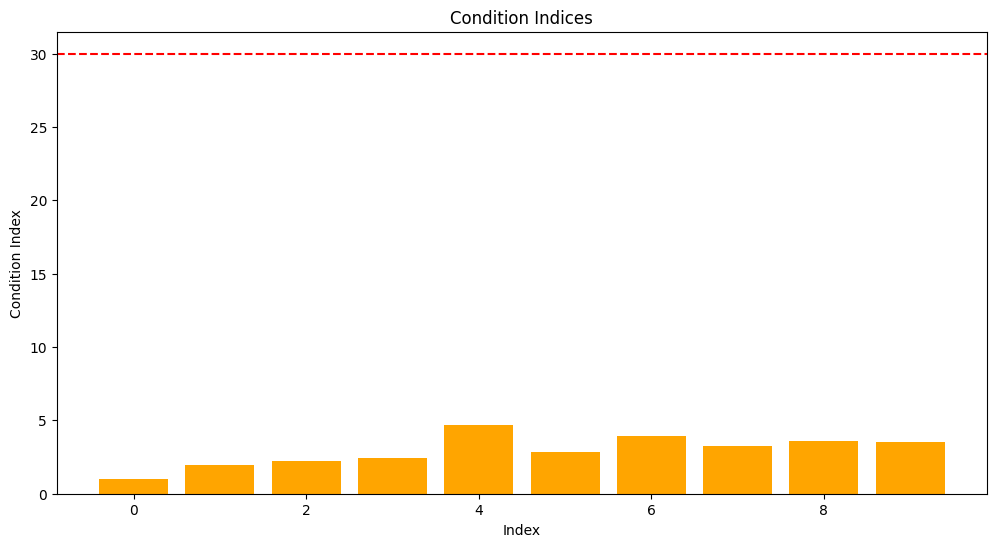

In [14]:
# 3. Condition Index and Eigenvalues
def condition_index(X):
    # Standardize the data
    X_standardized = (X - np.mean(X, axis=0)) / np.std(X, axis=0)

    # Calculate the covariance matrix
    covariance_matrix = np.cov(X_standardized, rowvar=False)

    # Calculate eigenvalues
    eigenvalues, _ = eig(covariance_matrix)

    # Calculate the condition index
    condition_indices = np.sqrt(eigenvalues.max() / eigenvalues)
    return condition_indices

# Calculate condition index
condition_indices = condition_index(returns.values)
print("\nCondition Indices:\n", condition_indices)

# Plot Condition Index
plt.figure(figsize=(12, 6))
plt.bar(range(len(condition_indices)), condition_indices, color='orange')
plt.axhline(y=30, color='r', linestyle='--')
plt.title('Condition Indices')
plt.xlabel('Index')
plt.ylabel('Condition Index')
plt.show()

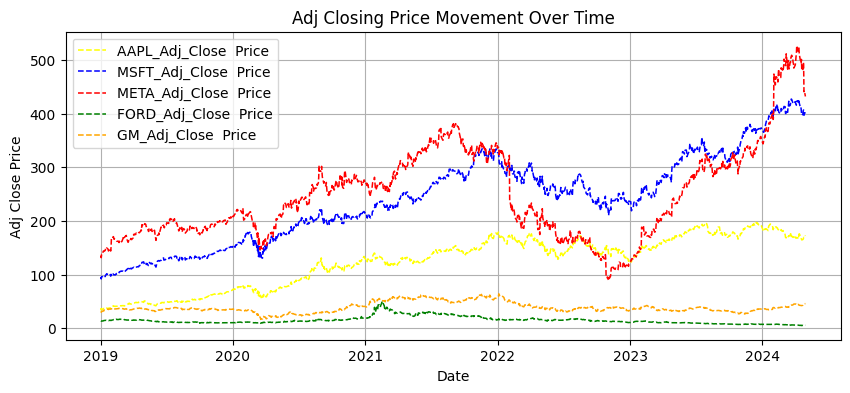

In [15]:
# Plotting the time series of Closing  Prices
fig = plt.subplots(figsize=(10, 4))
color=['yellow','blue','red','green','orange']
for id,col in enumerate(df.columns):

        if id<5:
        #df[col].plot(linewidth=0.8, label="Original "+col+ " stock price")
            plt.plot(df.index, df[col], label=col+'  Price', color=color[id], linestyle='--',linewidth=1.1)

plt.title('Adj Closing Price Movement Over Time')
plt.xlabel('Date')
plt.ylabel('Adj Close Price')
plt.legend()
plt.grid(True)
plt.show()

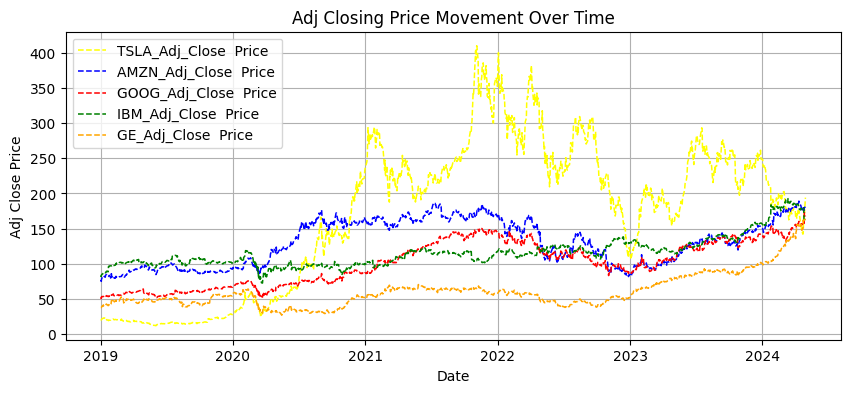

In [16]:
# Plotting the time series of Closing  Prices
fig = plt.subplots(figsize=(10, 4))
color=[0,0,0,0,0,'yellow','blue','red','green','orange']
for id,col in enumerate(df.columns):

        if id>=5:
        #df[col].plot(linewidth=0.8, label="Original "+col+ " stock price")
            plt.plot(df.index, df[col], label=col+'  Price', color=color[id], linestyle='--',linewidth=1.1)

plt.title('Adj Closing Price Movement Over Time')
plt.xlabel('Date')
plt.ylabel('Adj Close Price')
plt.legend()
plt.grid(True)
plt.show()

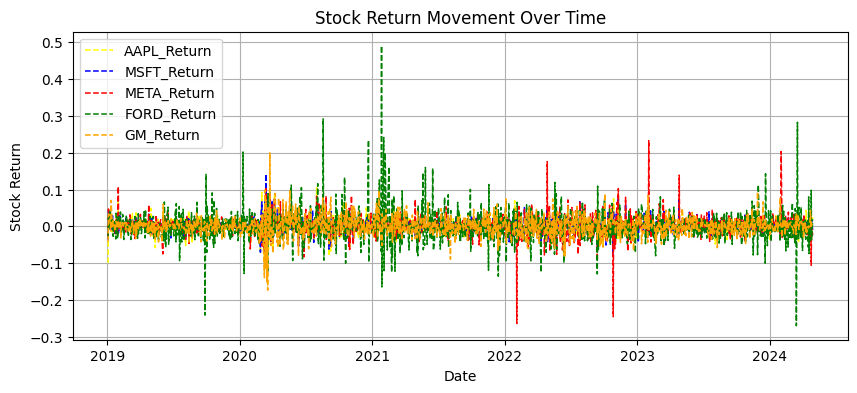

In [17]:
# add to colab
# Plotting the time series of Closing  Prices
fig = plt.subplots(figsize=(10, 4))
color=['yellow','blue','red','green','orange']
for id,col in enumerate(df2.columns):

        if id<5:
        #df[col].plot(linewidth=0.8, label="Original "+col+ " stock price")
            plt.plot(df2.index, df2[col], label=col, color=color[id], linestyle='--',linewidth=1.1)

plt.title('Stock Return Movement Over Time')
plt.xlabel('Date')
plt.ylabel('Stock Return')
plt.legend()
plt.grid(True)
plt.show()

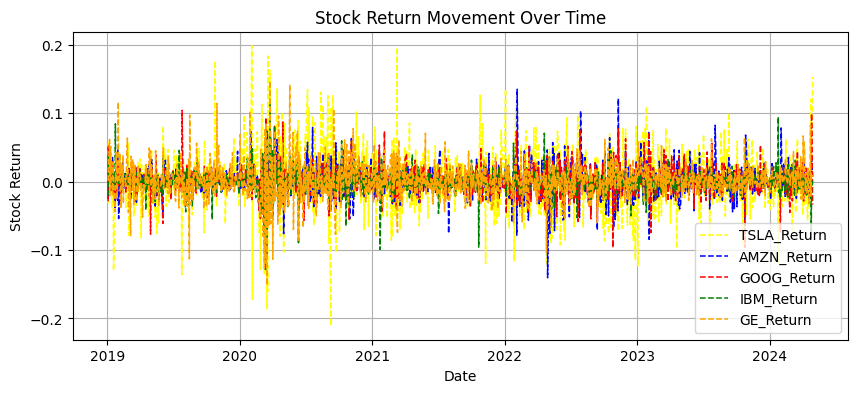

In [18]:
# add to colab
# Plotting the time series of Closing  Prices
fig = plt.subplots(figsize=(10, 4))
color=[0,0,0,0,0,'yellow','blue','red','green','orange']
for id,col in enumerate(df2.columns):

        if id>=5:
        #df[col].plot(linewidth=0.8, label="Original "+col+ " stock price")
            plt.plot(df2.index, df2[col], label=col, color=color[id], linestyle='--',linewidth=1.1)

plt.title('Stock Return Movement Over Time')
plt.xlabel('Date')
plt.ylabel('Stock Return')
plt.legend()
plt.grid(True)
plt.show()

## Category 3: Feature Extraction or Dimensionality Reduction
## using PCA on multivariate timeseries data

## Step : Standardizing the data

In [19]:
from sklearn.preprocessing import StandardScaler # for standardizing the Data
from sklearn.decomposition import PCA # for PCA calculation

X = df.values # getting all values as a matrix of dataframe
sc = StandardScaler() # creating a StandardScaler object
X_std = sc.fit_transform(X) # standardizing the data
X_std

array([[-1.83837717, -1.76972866, -1.30853394, ..., -1.5671253 ,
        -1.52022691, -0.96817623],
       [-1.91796976, -1.81239647, -1.35385174, ..., -1.61435688,
        -1.59759578, -0.96621543],
       [-1.88725605, -1.76043801, -1.28242441, ..., -1.52771025,
        -1.44924691, -0.93288965],
       ...,
       [ 0.94962529,  1.89920166,  2.2130171 , ...,  1.7832368 ,
         2.25856189,  4.19219934],
       [ 0.93716795,  1.98729673,  2.23500953, ...,  2.28234696,
         2.17789973,  4.23774774],
       [ 1.02584664,  1.93804543,  2.11215246, ...,  2.09874755,
         2.19149252,  4.32716998]])

## Step: Apply PCA

In [20]:
pca = PCA()
X_pca = pca.fit(X_std)

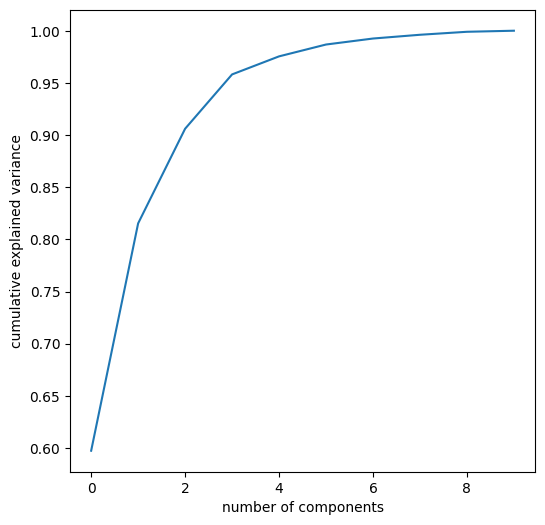

In [21]:
fig=plt.subplots(figsize=(6,6))
plt.plot(np.cumsum(X_pca.explained_variance_ratio_))
plt.xlabel('number of components')
plt.ylabel('cumulative explained variance')
plt.show();

## Step: Determine the number of components which can explain around 95%
## variance

In [22]:
pca3 = PCA(n_components = 0.95)
X_pca3 = pca3.fit_transform(X_std) # this will fit and reduce dimensions
print(pca3.n_components_)
# one can print and see how many components are selected. In this case it is 4 same as above we saw in step 5

4


In [23]:
pd.DataFrame(pca3.components_, columns = df.columns)

,AAPL_Adj_Close,MSFT_Adj_Close,META_Adj_Close,FORD_Adj_Close,GM_Adj_Close,TSLA_Adj_Close,AMZN_Adj_Close,GOOG_Adj_Close,IBM_Adj_Close,GE_Adj_Close
0,0.367838,0.392648,0.327194,0.043695,0.213754,0.330379,0.317086,0.395786,0.302076,0.313491
1,-0.072054,-0.142274,-0.003240,0.634290,0.463340,0.212530,0.274813,0.023495,-0.378238,-0.305355
2,-0.413664,-0.147498,0.557772,0.084731,0.217763,-0.499335,0.192264,-0.151730,0.107851,0.347075
3,0.044329,0.079284,0.335737,-0.152825,-0.563257,-0.001928,0.581218,-0.051201,-0.318823,-0.310368


In [24]:
data_pca = pca.fit_transform(X_std)

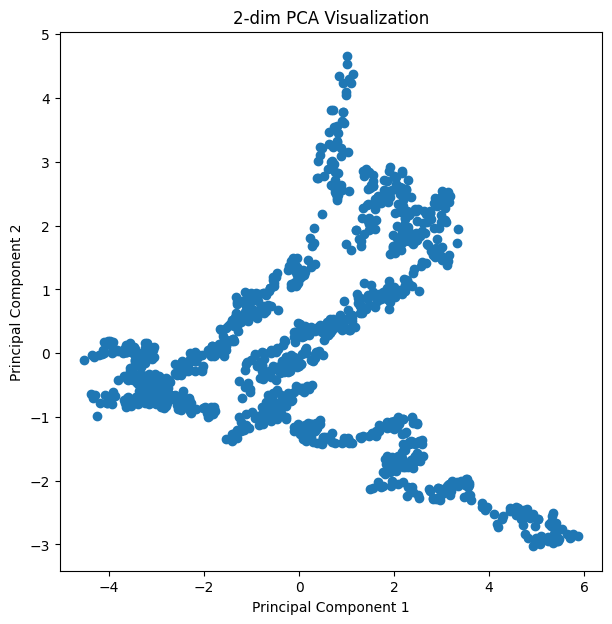

In [25]:
Fig=plt.subplots(figsize=(7,7))
plt.scatter(data_pca[:, 0], data_pca[:, 1])
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("2-dim PCA Visualization")
plt.show()

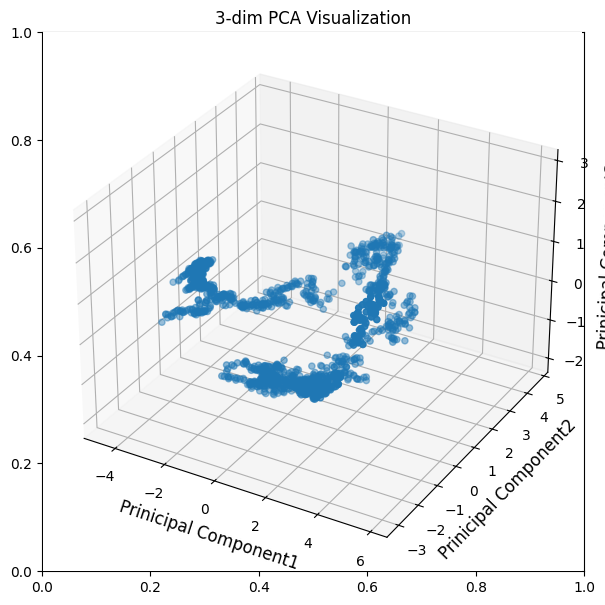

In [26]:
Fig=plt.subplots(figsize=(7,7))

# syntax for 3-D projection
ax = plt.axes(projection ='3d')


ax.scatter(data_pca[:, 0], data_pca[:, 1],data_pca[:,2])

# syntax for plotting
ax.set_title('3d Scatter plot')
ax.set_xlabel('Prinicipal Component1', fontsize=12)
ax.set_ylabel('Prinicipal Component2', fontsize=12,)
ax.set_zlabel('Prinicipal Component3', fontsize=12)
plt.title("3-dim PCA Visualization")
plt.show()

## Step : Finding the most important features set

In [27]:
n_pcs= pca3.n_components_ # get number of component
# get the index of the most important feature on EACH component
most_important = [np.abs(pca3.components_[i]).argmax() for i in range(n_pcs)]
initial_feature_names = df.columns
# get the most important feature names
most_important_names = [initial_feature_names[most_important[i]] for i in range(n_pcs)]
print (most_important_names)

['GOOG_Adj_Close', 'FORD_Adj_Close', 'META_Adj_Close', 'AMZN_Adj_Close']


In [28]:
most_important

[7, 3, 2, 6]

## Using these four features to predict IBM Adj Close

In [29]:
# OLS for revised model
model_1 = smf.ols(
    "IBM_Adj_Close ~ GOOG_Adj_Close+ FORD_Adj_Close + META_Adj_Close + AMZN_Adj_Close",
    data=df,
).fit()
model_1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          IBM_Adj_Close   R-squared:                       0.736
Model:                            OLS   Adj. R-squared:                  0.735
Method:                 Least Squares   F-statistic:                     928.9
Date:                Sat, 14 Dec 2024   Prob (F-statistic):               0.00
Time:                        22:03:45   Log-Likelihood:                -5120.6
No. Observations:                1340   AIC:                         1.025e+04
Df Residuals:                    1335   BIC:                         1.028e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         92.0936      1.301     70.788      0.000      89.541      94.646
GOOG_Adj_Close     0.4886      0.015     33.543      0.000       0.460       0.517
FORD_Adj_Close    -0.9419      0.056    -16.712      0.000      -1.052      -0.831
META_Adj_Close     0.1210      0.007     18.156      0.000       0.108       0.134
AMZN_Adj_Close    -0.3212      0.021    -15.162      0.000      -0.363      -0.280
==============================================================================
Omnibus:                       15.807   Durbin-Watson:                   0.037
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               16.071
Skew:                           0.253   Prob(JB):                     0.000324
Kurtosis:                       3.176   Cond. No.                     1.35e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.35e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

## Feature Extraction: Factor Analysis

In [30]:
from factor_analyzer import FactorAnalyzer
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity, calculate_kmo
from sklearn import preprocessing

In [31]:
data_normal = preprocessing.StandardScaler().fit_transform(df)
df5 = pd.DataFrame(data_normal, columns=[df2.columns])

## Conduct Bartlett's Test and Kaiser-Meyer-Olkin (KMO) Test

In [32]:
# Bartlett's Test
chi_square_value, p_value = calculate_bartlett_sphericity(df5)
print("chi_square_value =", chi_square_value, "\np_value =", p_value)

chi_square_value = 21940.865933847625 
p_value = 0.0


In [33]:
# Kaiser-Meyer-Olkin (KMO) Test
kmo_all, kmo_model = calculate_kmo(df5)
print("kmo_model =", kmo_model)

kmo_model = 0.7950375558710121


## Create 8-factor object and fit data

In [34]:
# Create 8-factor object and fit data
fa1 = FactorAnalyzer(8, rotation=None)
fact_res = fa1.fit(df5)

# Get Eigenvalues
ev, v = fact_res.get_eigenvalues()
ev

array([5.97437197, 2.17895605, 0.90715532, 0.5207541 , 0.1729575 ,
       0.11355338, 0.05744473, 0.03602876, 0.02861809, 0.01016011])

## Visualize eigenvalues on scree plot

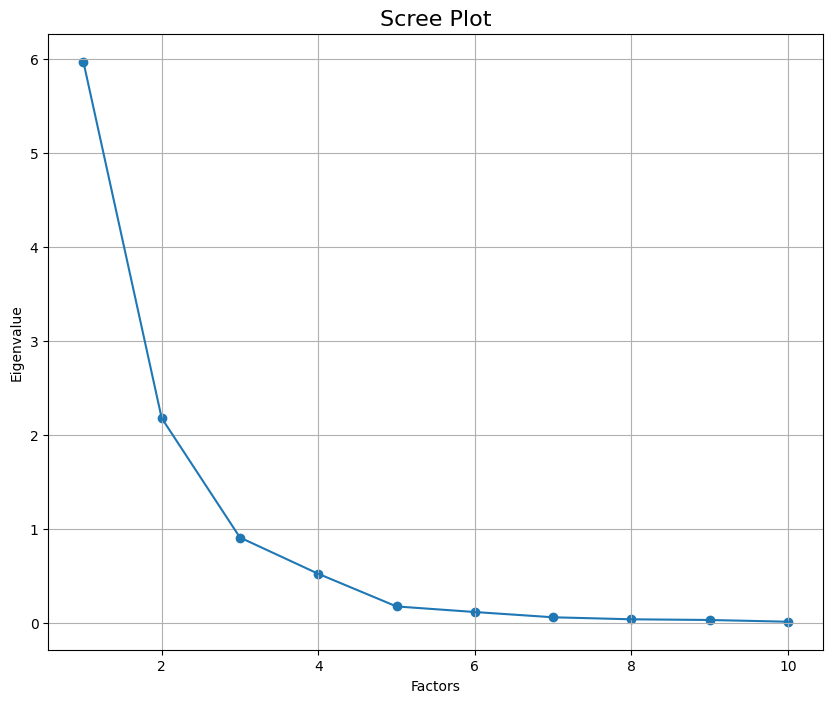

In [35]:
# Visualize eigenvalues on scree plot
plt.scatter(range(1, df5.shape[1] + 1), ev)
plt.plot(range(1, df5.shape[1] + 1), ev)
plt.title("Scree Plot", {"size": 16})
plt.xlabel("Factors")
plt.ylabel("Eigenvalue")
plt.grid()
plt.show()

## Results of eigenvalues and visualized Scree plot help us decide number of ## ## factors. In the Scree plot we can see that 3 eigenvalues are greater than 1 ## which in itself means that we need to chose 3-factor model. we will go ## for three factor model

## Create 3-factor object and fit data

In [36]:
# Create 3-factor object and fit data
fa3 = FactorAnalyzer(3, rotation=None)
fact_res3 = fa3.fit(df)

# Get uniquenesses
pd.DataFrame(
    fact_res3.get_uniquenesses(), index=[df2.columns], columns=["uniquenesses"]
)

,uniquenesses
AAPL_Return,0.038732
MSFT_Return,0.004416
META_Return,0.082116
FORD_Return,0.135216
GM_Return,0.371137
TSLA_Return,0.018147
AMZN_Return,0.263354
GOOG_Return,0.047359
IBM_Return,0.193626
GE_Return,0.164319


## Get Factor Loadings

In [37]:
# Get Factor Loadings
pd.DataFrame(
    fact_res3.loadings_,
    index=[df2.columns],
    columns=["Factor 1", "Factor 2", "Factor 3"]
)

,Factor 1,Factor 2,Factor 3
AAPL_Return,0.902918,-0.092942,-0.370633
MSFT_Return,0.968473,-0.206466,-0.122542
META_Return,0.793214,-0.004562,0.537286
FORD_Return,0.101358,0.918164,0.107172
GM_Return,0.491475,0.599670,0.166468
TSLA_Return,0.812688,0.341600,-0.452438
AMZN_Return,0.745884,0.381229,0.186998
GOOG_Return,0.968198,0.047129,-0.114073
IBM_Return,0.721908,-0.527927,0.080721
GE_Return,0.751646,-0.434744,0.285845


## Get proportion variance and cumulative proportion variance

In [38]:
# Get proportion variance and cumulative proportion variance
pd.DataFrame(
    fact_res3.get_factor_variance(),
    index=["Sum of squared loadings", "Proportional variance", "Cumulative variance"],
    columns=["Factor 1", "Factor 2", "Factor 3"],
)

,Factor 1,Factor 2,Factor 3
Sum of squared loadings,5.874545,1.985872,0.821163
Proportional variance,0.587455,0.198587,0.082116
Cumulative variance,0.587455,0.786042,0.868158


## Create 4-factor object with varimax or promax rotation and fit data

In [39]:
# Create 3-factor object with varimax rotation and fit data
fa3_varimax = FactorAnalyzer(n_factors=4, rotation="varimax", method="ml")
fact_res3_varimax = fa3_varimax.fit(df5)

# Get loadings
loadings_vrimax = pd.DataFrame(
    fact_res3_varimax.loadings_,
    index=[df2.columns],
    columns=["Factor 1", "Factor 2", "Factor 3","Factor 4"]
)

# Get factor variance
FactorVar_varimax = pd.DataFrame(
    fact_res3_varimax.get_factor_variance(),
    index=["Sum of squared loadings", "Proportional variance", "Cumulative variance"],
    columns=["Factor 1", "Factor 2", "Factor 3","Factor 4"]
)

# print the results
print("Loadings (varimax): \n", loadings_vrimax)
print("\nFactor Variance (varimax): \n", FactorVar_varimax)

Loadings (varimax): 
              Factor 1  Factor 2  Factor 3  Factor 4
AAPL_Return  0.893132  0.376496  0.016181  0.181953
MSFT_Return  0.751979  0.565419 -0.006982  0.331526
META_Return  0.185901  0.557150  0.191213  0.770613
FORD_Return  0.071638 -0.372721  0.763246  0.182332
GM_Return    0.209343  0.174109  0.931220  0.155599
TSLA_Return  0.901676  0.071192  0.345752  0.159937
AMZN_Return  0.460382  0.087206  0.348663  0.775420
GOOG_Return  0.755984  0.474032  0.243584  0.312592
IBM_Return   0.385351  0.824938 -0.153613  0.105660
GE_Return    0.251369  0.890208 -0.014759  0.242828

Factor Variance (varimax): 
                          Factor 1  Factor 2  Factor 3  Factor 4
Sum of squared loadings  3.254838  2.651471  1.810845  1.589015
Proportional variance    0.325484  0.265147  0.181085  0.158902
Cumulative variance      0.325484  0.590631  0.771715  0.930617


In [40]:
# Create 3-factor object with promax rotation and fit data
fa3_promax = FactorAnalyzer(n_factors=4, rotation="promax", method="ml")
fact_res3_promax = fa3_promax.fit(df5)

# Get loadings
loadings_promax = pd.DataFrame(
    fact_res3_promax.loadings_,
    index=[df2.columns],
    columns=["Factor 1", "Factor 2", "Factor 3","Factor 4"],
)

# Get factor variance
FactorVar_promax = pd.DataFrame(
    fact_res3_promax.get_factor_variance(),
    index=["Sum of squared loadings", "Proportional variance", "Cumulative variance"],
    columns=["Factor 1", "Factor 2", "Factor 3","Factor 4"],
)

# print the results
print("Loadings (promax): \n", loadings_promax)
print("\nFactor Variance (promax): \n", FactorVar_promax)

Loadings (promax): 
              Factor 1  Factor 2  Factor 3  Factor 4
AAPL_Return  0.960391  0.126357 -0.131844 -0.029899
MSFT_Return  0.670027  0.357319 -0.136759  0.172226
META_Return -0.226033  0.440984  0.021651  0.857651
FORD_Return  0.036688 -0.369182  0.689864  0.130239
GM_Return    0.002262  0.320295  1.037524 -0.100599
TSLA_Return  1.029052 -0.175259  0.170350 -0.076507
AMZN_Return  0.264118 -0.203579  0.003646  0.869939
GOOG_Return  0.670393  0.306230  0.137506  0.102934
IBM_Return   0.201226  0.840040 -0.055043 -0.082735
GE_Return   -0.060326  0.955445  0.096750  0.087745

Factor Variance (promax): 
                          Factor 1  Factor 2  Factor 3  Factor 4
Sum of squared loadings  3.045994  2.361472  1.649253  1.580989
Proportional variance    0.304599  0.236147  0.164925  0.158099
Cumulative variance      0.304599  0.540747  0.705672  0.863771


## Category 1: Model Comparison from OLS, Ridge Regression, and Lasso Regression


In [41]:
np.random.seed(11111)  # Random seed
nrow = df.shape[0]
train_sequence = sorted(np.random.choice(nrow, int(nrow * 0.8), replace=False))
test_sequence = sorted(set(list(range(0, nrow))) - set(train_sequence))

train = df.iloc[train_sequence,:]
test = df.iloc[test_sequence,:]


In [42]:
train.head()

,AAPL_Adj_Close,MSFT_Adj_Close,META_Adj_Close,FORD_Adj_Close,GM_Adj_Close,TSLA_Adj_Close,AMZN_Adj_Close,GOOG_Adj_Close,IBM_Adj_Close,GE_Adj_Close
Date,,,,,,,,,,
2019-01-02,37.708595,95.310555,135.272705,13.4,31.090395,20.674667,76.956497,52.105282,83.291313,37.646240
2019-01-03,33.952534,91.804260,131.344543,13.0,29.805744,20.024000,75.014000,50.621113,81.628540,37.693016
2019-01-04,35.401947,96.074028,137.535889,13.4,30.803890,21.179333,78.769501,53.343830,84.816780,38.488018
2019-01-07,35.323147,96.196533,137.635605,13.5,31.755823,22.330667,81.475502,53.228245,85.416809,40.873066
2019-01-08,35.996521,96.894005,142.102142,13.4,32.171726,22.356667,82.829002,53.621330,86.631363,40.031284


## we try to predict Amazon Stock Price from other nine variables..

In [43]:
# Make sure X matrix is in matrix form and Y is in vector form
ind_var = ["AAPL_Adj_Close", "MSFT_Adj_Close", "META_Adj_Close", "FORD_Adj_Close", "GM_Adj_Close","TSLA_Adj_Close",
           "GOOG_Adj_Close","IBM_Adj_Close",
           "GE_Adj_Close"]

train_x = train.loc[:, ind_var]
train_y = train.AMZN_Adj_Close
test_x = test.loc[:, ind_var]
test_y = test.AMZN_Adj_Close

test_tot = test.loc[:, ["AMZN_Adj_Close","AAPL_Adj_Close", "MSFT_Adj_Close", "META_Adj_Close", "FORD_Adj_Close",
                        "GM_Adj_Close","TSLA_Adj_Close",
                        "GOOG_Adj_Close","IBM_Adj_Close", "GE_Adj_Close"]]


## OLS Regression

In [44]:
ols_final = sm.OLS(train_y, sm.add_constant(train_x)).fit()
print(ols_final.summary2().tables[1])  # print only coefficients

# Compute test R^2 and test mean squared error
ols_pred = ols_final.predict(sm.add_constant(test_x))
ols_pred = pd.DataFrame(ols_pred, columns=["ols_p"])
ols_actual = test.AMZN_Adj_Close

ols_rss = np.sum(np.power(ols_pred.ols_p - ols_actual, 2))
ols_tss = np.sum(np.power(ols_actual - np.mean(ols_actual), 2))
ols_rsq = 1 - (ols_rss / ols_tss)
print("\n OLS_R^2", ols_rsq)

ols_MSE = np.sqrt(ols_rss / test.shape[0])
print(" OLS_SME", ols_MSE)


                    Coef.  Std.Err.          t          P>|t|     [0.025  \
const           46.848272  2.952465  15.867509   4.817201e-51  41.054944   
AAPL_Adj_Close  -0.021453  0.035708  -0.600788   5.481095e-01  -0.091519   
MSFT_Adj_Close   0.118094  0.030277   3.900423   1.020572e-04   0.058684   
META_Adj_Close   0.336938  0.008457  39.841052  4.879808e-213   0.320344   
FORD_Adj_Close   1.007394  0.083582  12.052728   1.905329e-31   0.843389   
GM_Adj_Close    -0.218353  0.069426  -3.145121   1.706303e-03  -0.354580   
TSLA_Adj_Close   0.109705  0.011541   9.505418   1.279767e-20   0.087059   
GOOG_Adj_Close  -0.183209  0.044604  -4.107434   4.308180e-05  -0.270731   
IBM_Adj_Close    0.028603  0.035860   0.797620   4.252691e-01  -0.041762   
GE_Adj_Close    -0.592879  0.033893 -17.492606   2.110726e-60  -0.659384   

                   0.975]  
const           52.641601  
AAPL_Adj_Close   0.048613  
MSFT_Adj_Close   0.177504  
META_Adj_Close   0.353533  
FORD_Adj_Close   1.1713

## Ridge Regression ##

In [45]:
# generate a sequence of lambdas to try
lambdas = [np.power(10, i) for i in np.arange(4, -4, -0.1)]
alphas = lambdas

# Scale
# train_x_scale = scale(train_x) #In case you want to scale the variables.

# Use 10-fold Cross Validation to find optimal lambda
ridge_cv = RidgeCV(alphas=alphas, cv=10, scoring="neg_mean_squared_error")
ridge_cv.fit(train_x, train_y)

# Build final ridge regression model
ridge_final = Ridge(alpha=ridge_cv.alpha_, fit_intercept=True)
ridge_final.fit(train_x, train_y)

# Print coefficients
# print('Intercept:', ridge_final.intercept_)
print(
    "\n",
    pd.DataFrame(
        (ridge_final.coef_),
        index=ind_var,
        columns=["Coef."],
    ),
)

# R squared formula and mean squared error
ridge_pred = ridge_final.predict(test_x)
ridge_actual = test.AMZN_Adj_Close
ridge_rss = np.sum(np.power(ridge_pred - ridge_actual, 2))
ridge_tss = np.sum(np.power(ridge_actual - np.mean(ridge_actual), 2))
ridge_rsq = 1 - ridge_rss / ridge_tss
print("\n Ridge_R^2", ridge_rsq)

ridge_MSE = np.sqrt(ridge_rss / test.shape[0])
print("Ridge_SME", ridge_MSE)



                    Coef.
AAPL_Adj_Close  0.010588
MSFT_Adj_Close  0.068828
META_Adj_Close  0.343575
FORD_Adj_Close  0.587404
GM_Adj_Close   -0.068586
TSLA_Adj_Close  0.117769
GOOG_Adj_Close -0.146720
IBM_Adj_Close  -0.024275
GE_Adj_Close   -0.558334

 Ridge_R^2 0.9111106864188839
Ridge_SME 9.58469200251163


## LASSO Regression ##

In [46]:
# generate a sequence of lambdas to try
lambdas = [np.power(10, i) for i in np.arange(6, -6, -0.1)]

# Compile model
lasso_cv = LassoCV(cv=10, alphas=lambdas)
lasso_cv.fit(train_x, train_y)  # Fit Model

# Scale
# train_x_scale = scale(train_x) #In case you want to scale the variables.
print ("#################################################")
print ("lasso_cv.alpha_:", lasso_cv.alpha_)
print ()
# Build final LASSO regression model
lasso_final = Lasso(alpha=lasso_cv.alpha_, fit_intercept=True)
lasso_final.fit(train_x, train_y)

# Print results
# print('Intercept:', lasso_final.intercept_)
print(
    "\n",
    pd.DataFrame(
        (lasso_final.coef_),
        index=ind_var,
        columns=["Coef."],
    ),
)

# R squared formula and mean squared error
lasso_pred = lasso_final.predict(test_x)
lasso_actual = test.AMZN_Adj_Close
lasso_rss = np.sum(np.power(lasso_pred - lasso_actual, 2))
lasso_tss = np.sum(np.power(lasso_actual - np.mean(lasso_actual), 2))
lasso_rsq = 1 - lasso_rss / lasso_tss
print("\n LASSO_R^2: ", lasso_rsq)

lasso_MSE = np.sqrt(lasso_rss / test.shape[0])
print("LASSO_SME: ", lasso_MSE)



#################################################
lasso_cv.alpha_: 31.622776601684958


                    Coef.
AAPL_Adj_Close -0.000000
MSFT_Adj_Close -0.012570
META_Adj_Close  0.334618
FORD_Adj_Close  0.000000
GM_Adj_Close    0.000000
TSLA_Adj_Close  0.135061
GOOG_Adj_Close -0.000000
IBM_Adj_Close  -0.000000
GE_Adj_Close   -0.487969

 LASSO_R^2:  0.8866444378391379
LASSO_SME:  10.823676486197071


In [47]:
OLS_df = pd.DataFrame(ols_final.summary2().tables[1]["Coef."]).rename(
    columns={"Coef.": "OLS"}
)

Ridge_df = pd.DataFrame(
    np.insert(ridge_final.coef_, 0, ridge_final.intercept_),
    index=["Intercept",
           "AAPL_Adj_Close", "MSFT_Adj_Close", "META_Adj_Close", "FORD_Adj_Close", "GM_Adj_Close","TSLA_Adj_Close",
           "GOOG_Adj_Close","IBM_Adj_Close",
           "GE_Adj_Close"
          ],
    columns=["Ridge"],
)

Lasso_df = pd.DataFrame(
    np.insert(lasso_final.coef_, 0, lasso_final.intercept_),
    index=["Intercept",
           "AAPL_Adj_Close", "MSFT_Adj_Close", "META_Adj_Close", "FORD_Adj_Close", "GM_Adj_Close","TSLA_Adj_Close",
           "GOOG_Adj_Close","IBM_Adj_Close",
           "GE_Adj_Close"
          ],
    columns=["Lasso"],
)

df4 = OLS_df.merge(
       pd.DataFrame(
        (ridge_final.coef_),
        index=ind_var,
        columns=["Ridge"]),
      left_index=True, right_index=True)
df4 = df4.merge(
                 pd.DataFrame(
        (lasso_final.coef_),
        index=ind_var,
        columns=["Lasso"]),
               left_index=True, right_index=True)

df5 =  pd.DataFrame(
        {
           "OLS":  [ols_rsq, ols_MSE],
           "Ridge":  [ridge_rsq, ridge_MSE],
           "Lasso":  [lasso_rsq, lasso_MSE],
        },
        index=["R sq", "Mean Sq. Err"],

      )

df4=pd.concat([df4,df5],
    ignore_index=False,
)

print (df4)

                     OLS     Ridge      Lasso
AAPL_Adj_Close -0.021453  0.010588  -0.000000
MSFT_Adj_Close  0.118094  0.068828  -0.012570
META_Adj_Close  0.336938  0.343575   0.334618
FORD_Adj_Close  1.007394  0.587404   0.000000
GM_Adj_Close   -0.218353 -0.068586   0.000000
TSLA_Adj_Close  0.109705  0.117769   0.135061
GOOG_Adj_Close -0.183209 -0.146720  -0.000000
IBM_Adj_Close   0.028603 -0.024275  -0.000000
GE_Adj_Close   -0.592879 -0.558334  -0.487969
R sq            0.916614  0.911111   0.886644
Mean Sq. Err    9.283262  9.584692  10.823676


## Lasso Penalized Regression has made the coeff of Apple, Ford, Google,
## IBM, GM to equal to zero,,
## thus reducing the nine variables to four...
## thus helping in feature extraction..
## and coef of MSFT is also close to zero i.e. -0.013
## and Ridge is giving R-squared as 91%..